# Si：联合拟合 FC2–FC5，再计算热导率

从配套的硅位移与力样本联合恢复二阶到五阶力常数，检查拟合力误差与声子谱，再将 FC2、FC3 交给 phono3py 计算 RTA 热导率。

这里读取已经保存的力，不重新启动 calculator。结构与 100 帧训练数据位于 `data/si`，环境准备见[教程总览](index.md)。

## 1. 读取与训练样本配套的结构

2 原子的金刚石原胞和 $4\times4\times4$、128 原子超胞是模型与数据之间的基准。参考超胞的原子顺序必须与 `train.xyz` 相同，MLFCS 不会按元素自动修复同种原子的重排。

换成自己的材料，需要替换参考原胞、理想超胞和带力轨迹；单位统一为 Å 与 eV/Å。

In [1]:
from pathlib import Path
import logging
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read, iread
from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FitSystem
from mlfcs.phonon import Harmonic
from mlfcs.tools import EstimateCutoff

logging.getLogger("mlfcs").setLevel(logging.WARNING)
DATA = Path("data/si")
if not DATA.exists():
    DATA = Path("docs/notebooks") / DATA
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-si-fit-"))
primitive = read(DATA / "POSCAR")
supercell = read(DATA / "SPOSCAR")
print(f"原胞：{len(primitive)} 原子；超胞：{len(supercell)} 原子")

原胞：2 原子；超胞：128 原子


## 2. 按近邻壳层选择截断

随着阶数增加，参数量很快增长。本例二阶保留前 7 壳、三阶前 6 壳、四阶前 3 壳、五阶前 2 壳。壳间中点可避免让半径恰好落在一个近邻距离上；实际给模型的输入仍是正的 Å 半径。

这些范围是本例的教学选择，不是对任何硅模型都适用的物理截断。换材料或采样温度后，需要重新检查。

In [2]:
shells = EstimateCutoff(primitive)
shell_counts = {2: 7, 3: 6, 4: 3, 5: 2}
cutoffs = {order: shells.get(count) for order, count in shell_counts.items()}
for order, cutoff in cutoffs.items():
    print(f"FC{order}：保留前 {shell_counts[order]} 壳，截断 {cutoff:.3f} Å")

FC2：保留前 7 壳，截断 7.419 Å
FC3：保留前 6 壳，截断 6.901 Å
FC4：保留前 3 壳，截断 5.001 Å
FC5：保留前 2 壳，截断 4.201 Å


## 3. 定义模型，再检查超胞是否足够

最大体阶 2、3、4、3 限制各阶涉及的不同原子位置数。五阶最多三个位置，是控制规模的一项模型近似，不代表只保留三阶导数；阶数与体阶是两件事。

`asr=True` 让所有拟合阶数在各自的平移约束空间中求解。`rank_info().require_full()` 检查超胞折叠是否丢失参数信息；它通过并不保证训练数据也足够丰富。

In [3]:
space = ClusterSpace(primitive, cutoffs=cutoffs,
                     max_body_orders={2: 2, 3: 3, 4: 4, 5: 3}, asr=True)
mapping = ClusterMap(space, supercell)
mapping.rank_info().require_full()
print(f"物理参数：{space.n_parameters}；ASR 自由参数：{space.n_free_parameters}")

物理参数：1771；ASR 自由参数：1172


## 4. 收集带力结构

`iread` 逐帧读取 `train.xyz`。`ForceDataset` 保存相对于参考超胞的最小像位移及已有力，既不重新计算力，也不对训练目标做隐式减均值。

本例使用文件中的全部 100 帧。若有另一批独立位移样本，可用相同 mapping 再建验证数据集。

In [4]:
dataset = ForceDataset(mapping, iread(DATA / "train.xyz", index=":"))
print(f"训练样本：{len(dataset.forces)} 帧")

训练样本：100 帧


## 5. 一次联合求解全部阶数

`representation="raw"` 保存原始力方程并用列缩放后的直接最小二乘求解，无需设置迭代容差。四个阶数共同解释每一帧力，不是先后独立拟合四次。

保留设计矩阵及求解副本会占用较多内存。更大数据集可考虑[拟合章节](../fitting-api.md)中的正规表示，但两条路线的数值精度与内存代价不同。

下方只报告训练力误差。高阶项能解释更多位移依赖，不保证低阶参数或预测结果必然更好。

In [5]:
system = FitSystem(dataset, representation="raw")
model = system.solve()
print(f"力 RMSE：{system.rmse(model):.5f} eV/Å")
print(f"力相对误差：{system.relative_error(model):.3%}")

力 RMSE：0.02577 eV/Å
力相对误差：2.997%


## 6. 检查联合拟合中的二阶部分

`Harmonic` 使用模型的 FC2 计算声子谱；FC3–FC5 不直接进入这张谐波图。自动高对称路径由 ASE 生成，200 个 q 点只是绘图取样。

曲线连续性、明显虚频和 Γ 附近的行为可提示问题，但训练误差小不能替代独立验证与截断收敛。

声子路径：GXWKGLUWLK,UX


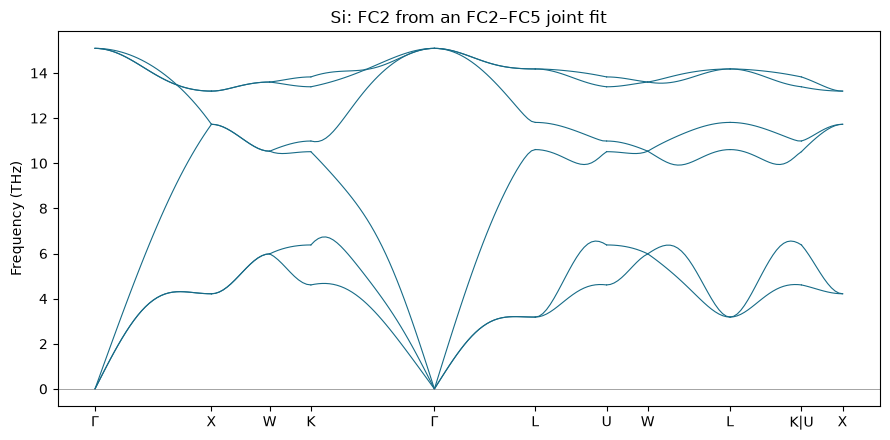

In [6]:
bands = Harmonic(model).run_band_path(npoints=200)
print(f"声子路径：{bands.path}")
fig, axis = plt.subplots(figsize=(9, 4.5))
for segment in bands.segments:
    axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color="#176b87", lw=0.8)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
axis.axhline(0, color="0.5", lw=0.5)
axis.set_ylabel("Frequency (THz)")
axis.set_title("Si: FC2 from an FC2–FC5 joint fit")
fig.tight_layout()
plt.show()

## 7. 导出输运所需的 FC2 和 FC3

phono3py 的三声子 RTA 消费二阶与三阶张量，本例拟合出的 FC4、FC5 不直接参加散射计算。它们只通过联合拟合影响得到的参数。

输出写进临时目录，研究计算可替换成持久工作目录。下面用参考超胞作为 phono3py 输入晶胞，以单位超胞矩阵保持文件排序，再以 MLFCS 超胞矩阵的逆的转置给出原胞变换。Phonopy 按列给出变换，而 MLFCS 的超胞矩阵按行给出。首指标按 `p2s_map` 选择原胞代表原子。

In [7]:
fc2_file = SCRATCH / "fc2.hdf5"
fc3_file = SCRATCH / "fc3.hdf5"
model.write(fc2_file, mapping, format="phonopy", storage="hdf5", order=2)
model.write(fc3_file, mapping, format="phono3py", storage="hdf5", order=3)
from phono3py import Phono3py
from phono3py.file_IO import read_fc2_from_hdf5, read_fc3_from_hdf5
from phonopy.structure.atoms import PhonopyAtoms

unitcell = PhonopyAtoms(
    symbols=supercell.get_chemical_symbols(), cell=supercell.cell.array,
    scaled_positions=supercell.get_scaled_positions(), masses=supercell.get_masses(),
)
ph3 = Phono3py(unitcell, np.eye(3, dtype=int),
               primitive_matrix=np.linalg.inv(mapping.supercell_matrix).T, log_level=0)
p2s = ph3.phonon_primitive.p2s_map
ph3.fc2 = read_fc2_from_hdf5(str(fc2_file))[p2s]
ph3.fc3 = read_fc3_from_hdf5(str(fc3_file))[p2s]

## 8. 计算温度序列的 RTA 热导率

用 $10\times10\times10$ q 网格，在 300–900 K 每隔 100 K 计算一次，并包含天然同位素散射。这份 FC2、FC3 在温度序列中固定不变；变化的是输运计算的热占据，不是每个温度重新拟合的模型。

`write_kappa=False` 把结果留在内存与 notebook 输出中。这里的网格是演示设置，不能把结果表当作已收敛的材料热导率。

In [8]:
TEMPERATURES = tuple(range(300, 901, 100))
ph3.mesh_numbers = (10, 10, 10)
ph3.init_phph_interaction()
ph3.run_thermal_conductivity(temperatures=TEMPERATURES, is_isotope=True,
                            write_kappa=False, log_level=0)
kappa = ph3.thermal_conductivity.kappa.reshape(-1, 6)
print("T (K)    κxx       κyy       κzz   [W/(m·K)]")
for temperature, values in zip(TEMPERATURES, kappa):
    print(f"{temperature:5g}  {values[0]:8.3f}  {values[1]:8.3f}  {values[2]:8.3f}")

T (K)    κxx       κyy       κzz   [W/(m·K)]
  300   115.338   115.338   115.338
  400    83.705    83.705    83.705
  500    66.131    66.131    66.131
  600    54.820    54.820    54.820
  700    46.883    46.883    46.883
  800    40.987    40.987    40.987
  900    36.427    36.427    36.427


## 接下来

我们用一套力样本联合拟合了 FC2–FC5，检查二阶模型，并完成了 FC2、FC3 的外部输运计算。二阶、三阶张量用于输运，其余阶数仍保存在联合拟合的模型中。

换材料时重点修改结构、训练数据、各阶截断和体阶；做定量输运还需检查 q 网格与散射模型。数学背景见[力常数恢复](../theory/reconstruction.md)。

下一份 [K4As4Pt2 教程](k4as4pt2.ipynb)使用四阶项进行 SCPH，比较随温度变化的有效声子谱。